# Cold-Start Forecaster — drop a pin → expected 5-year car-wash counts

**Goal.** Given a *location* (and optionally the *operator*) for a **site that doesn't exist yet**, predict its
**monthly wash count over the next 5 years** (membership + retail), plus the **impact on neighbouring sites**.

**Why not MOIRAI?** MOIRAI (and any time-series model) forecasts by reading an *existing* history. A dropped pin has
**zero history** — this is a **cold-start** problem, which needs a model mapping **location + market context → trajectory**.

**Hybrid model** (built in [`../streamlits/coldstart_model.py`](../streamlits/coldstart_model.py), reused here and by the app):

$$\text{washes}(m) \;=\; \underbrace{\text{PLATEAU level}}_{\text{geo + market + operator} \to \text{LightGBM}}\;\times\;\underbrace{\text{RAMP shape}(m)}_{\text{learned ramp curve}}$$

- **Plateau** — LightGBM quantile regression on location + local-market features (+ **operator/brand**, the dominant driver) → mature monthly washes & membership share, with P10–P90 bands.
- **Ramp** — empirical normalized ramp curves (membership ramps over ~7 mo; retail ~flat from month 1), held flat at the plateau after ~month 30; optional secular drift for years 3–5.
- **Neighbours** — projected flat, then the learned **cannibalization-by-distance** (§7-B) subtracted from their retail.

> **Honest framing.** The **ramp shape is well-learned**; the **plateau level is the uncertain part** — ~28% median error with a known operator, and only a weak region prior for a pin in a fresh area (no neighbours). Bands reflect this; the app also lets you override the plateau.

## 0. Setup — load data, features, trained model

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); plt.rcParams.update({'figure.dpi':110})
sys.path.insert(0, str(Path('../streamlits').resolve()))
import coldstart_model as cm
FIG = Path('figures'); FIG.mkdir(exist_ok=True)

panel, site = cm.load_panel_site()
S, _tree = cm.build_features(panel, site)
art = cm.load()          # trains + caches on first call
lab = S[S.mat_n>=4].copy()
print(f'sites={len(S)} | labelled (mature, ≥4 obs in months 18-30)={len(lab)} | trained model on {art["n_train"]} sites')
print('multi-site operators (brand signal available):', (lab.brand_n>1).sum())

sites=1947 | labelled (mature, ≥4 obs in months 18-30)=1272 | trained model on 1272 sites
multi-site operators (brand signal available): 879


## 1. Local-market clustering — density-aware (the strategy we use)

A single fixed radius is wrong for this data: 20 km **chains** dense metros into sprawling "markets" (diameter > 100 km), while sparser regions need the full 20 km to link related sites. So we use a **density-aware** scheme: a site links to a neighbour only within **min(rᵢ, rⱼ)**, where a site's radius is **10 km if it already has ≥5 neighbours within 10 km (dense), else 20 km (sparse)**; connected components form markets, components wider than 25 km are re-split (kills chaining), and isolated sites are **standalone** (shown in grey on the map). We bake it off against the fixed-20 km DBSCAN and HDBSCAN on the metric that matters — **within-cluster co-movement** (do same-market series actually move together?).

In [2]:
from sklearn.cluster import HDBSCAN
g = site[site.has_coords].reset_index(drop=True); radg = np.radians(g[['lat','lon']].values); EK = cm.EARTH_KM
dd = panel.merge(g[['site_key']], on='site_key'); dd['moy']=dd.date.dt.month; dd['reg']=dd['region'].fillna('NA') if 'region' in dd else 'NA'
rm=dd.groupby(['reg','moy']).tot_wash_count.transform('mean'); rr=dd.groupby('reg').tot_wash_count.transform('mean')
dd['des']=dd.tot_wash_count/(rm/rr).replace(0,np.nan)
W=dd.pivot_table(index='date',columns='site_key',values='des').apply(lambda s:s-s.rolling(7,center=True,min_periods=3).mean())
rng=np.random.default_rng(0)
def _diam(lab):
    out=[]
    for c in set(lab):
        if c<0: continue
        idx=np.where(lab==c)[0]
        if len(idx)<2: continue
        r=radg[idx]; a=np.sin((r[:,:1]-r[:,:1].T)/2)**2+np.cos(r[:,:1])*np.cos(r[:,:1].T)*np.sin((r[:,1:]-r[:,1:].T)/2)**2
        out.append(float((2*EK*np.arcsin(np.sqrt(np.clip(a,0,1)))).max()))
    return np.array(out) if out else np.array([0.0])
def _wcorr(lab, cap=15000):
    keys=g.site_key.values; cs=[]
    for c in set(lab):
        if c<0: continue
        mem=[keys[i] for i in np.where(lab==c)[0] if keys[i] in W.columns]
        for i in range(len(mem)):
            for j in range(i+1,len(mem)):
                v=W[mem[i]].corr(W[mem[j]])
                if np.isfinite(v): cs.append(v)
    cs=np.array(cs)
    if len(cs)>cap: cs=rng.choice(cs,cap,replace=False)
    return np.median(cs) if len(cs) else np.nan
labs={'A: DBSCAN 20km (fixed)':cm.assign_clusters(g,'dbscan20'),
      'B: adaptive 10/20km (USED)':cm.assign_clusters(g,'adaptive'),
      'C: HDBSCAN':HDBSCAN(min_cluster_size=2,min_samples=1,metric='haversine').fit(radg).labels_}
rows=[[nm,len(set(l[l>=0])),f'{(l>=0).mean()*100:.0f}%',f'{np.median(_diam(l)):.1f}',f'{np.percentile(_diam(l),90):.1f}',f'{_wcorr(l):.3f}'] for nm,l in labs.items()]
print(pd.DataFrame(rows,columns=['strategy','clusters','coverage','diam med km','diam p90 km','within-cluster r']).to_string(index=False))
print('\nVerdict: B (adaptive) — higher within-cluster co-movement than fixed-20km AND bounded diameter (no chaining) AND finer markets. ADOPTED.')

                  strategy  clusters coverage diam med km diam p90 km within-cluster r
    A: DBSCAN 20km (fixed)       235      82%        13.4        49.7            0.521
B: adaptive 10/20km (USED)       387      80%        13.8        21.3            0.594
                C: HDBSCAN       567      85%         7.4        41.0            0.605

Verdict: B (adaptive) — higher within-cluster co-movement than fixed-20km AND bounded diameter (no chaining) AND finer markets. ADOPTED.


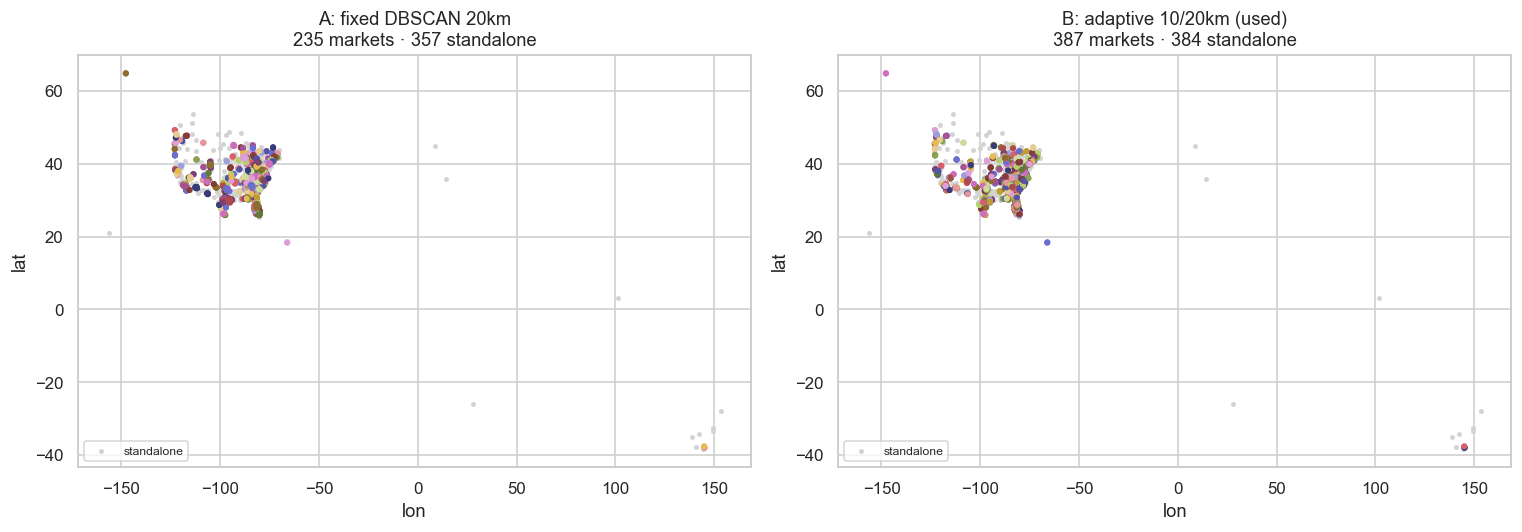

In [3]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
for k,(nm,key) in enumerate([('A: fixed DBSCAN 20km','dbscan20'),('B: adaptive 10/20km (used)','adaptive')]):
    cl=cm.assign_clusters(g,key); noise=cl<0
    ax[k].scatter(g.lon[noise], g.lat[noise], s=5, c='lightgray', label='standalone')
    ax[k].scatter(g.lon[~noise], g.lat[~noise], s=9, c=(cl[~noise]*131%40), cmap='tab20b')
    ax[k].set(title=f'{nm}\n{len(set(cl[cl>=0]))} markets · {int(noise.sum())} standalone', xlabel='lon', ylabel='lat')
    ax[k].legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'cs0_clustering.png',bbox_inches='tight'); plt.show()

## 2. Plateau-level model — how busy will it get?

The hard part. We evaluate two honest scenarios with cross-validation:
- **LOSO** (leave-one-*site*-out, KFold) — *a pin in a populated market*: the new site's neighbours exist, so neighbour features are available. **This is the main use case.**
- **LOCO** (leave-one-*cluster*-out, GroupKFold) — *a pin in a fresh area*: no local neighbours, so the model leans on the region prior. The hard case.

Compared against naive baselines (global/region median, nearest-site level).

SCENARIO                         R^2     MAE(washes)   MAPE
LOSO (pin in populated market)    0.33       2811    27%
LOCO (pin in FRESH area)          0.30       2996    30%
baseline: region median          ---       ---       40%
baseline: nearest-site level      ---       ---       46%


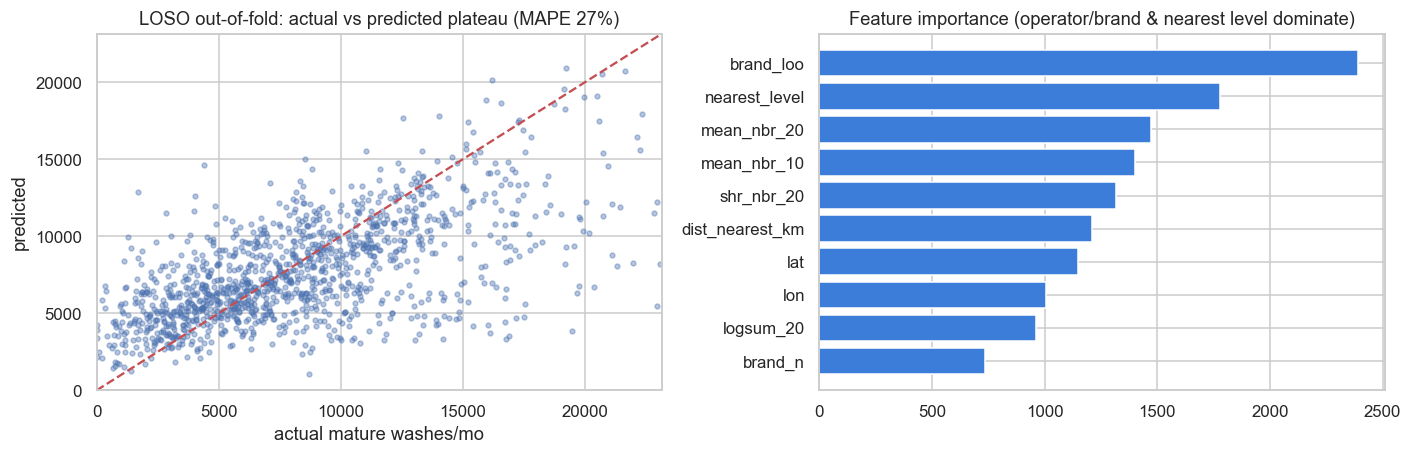

In [4]:
import lightgbm as lgb
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
L = lab.copy(); L['y']=np.log1p(L.mat_total); L['share']=(L.mat_mem/L.mat_total).clip(0,1)
for c in cm.CAT: L[c]=L[c].astype('category')
X=L[cm.FEAT+cm.CAT]; y=L.y.values; a=np.expm1(y)
def mdl(): return lgb.LGBMRegressor(objective='quantile',alpha=0.5,n_estimators=500,learning_rate=0.03,
    num_leaves=31,min_child_samples=20,subsample=0.8,colsample_bytree=0.8,verbose=-1)
def cv(splitter, groups=None):
    pred=np.zeros(len(y)); it=splitter.split(X,y,groups) if groups is not None else splitter.split(X)
    for tr,te in it:
        m=mdl(); m.fit(X.iloc[tr],y[tr],categorical_feature=cm.CAT); pred[te]=m.predict(X.iloc[te])
    p=np.expm1(pred)
    return pred, (r2_score(y,pred), mean_absolute_error(a,p), np.median(np.abs(a-p)/a)*100)
oof, (r2k,maek,mapek) = cv(KFold(5,shuffle=True,random_state=0))
_,   (r2g,maeg,mapeg) = cv(GroupKFold(5), L.cluster.values)
regmed=L.groupby('region').mat_total.transform('median'); nn=L.nearest_level.replace(0,np.nan).fillna(np.median(a))
print('SCENARIO                         R^2     MAE(washes)   MAPE')
print(f'LOSO (pin in populated market)   {r2k:5.2f}   {maek:8.0f}    {mapek:.0f}%')
print(f'LOCO (pin in FRESH area)         {r2g:5.2f}   {maeg:8.0f}    {mapeg:.0f}%')
print(f'baseline: region median          ---       ---       {np.median(np.abs(a-regmed)/a)*100:.0f}%')
print(f'baseline: nearest-site level      ---       ---       {np.median(np.abs(a-nn)/a)*100:.0f}%')

fig,ax=plt.subplots(1,2,figsize=(13,4.3))
ax[0].scatter(a, np.expm1(oof), s=10, alpha=.4); lim=[0,np.percentile(a,99)]
ax[0].plot(lim,lim,'r--'); ax[0].set(title=f'LOSO out-of-fold: actual vs predicted plateau (MAPE {mapek:.0f}%)',
    xlabel='actual mature washes/mo', ylabel='predicted', xlim=lim, ylim=lim)
mf=mdl(); mf.fit(X,y,categorical_feature=cm.CAT)
imp=pd.Series(mf.feature_importances_, index=cm.FEAT+cm.CAT).sort_values().tail(10)
ax[1].barh(imp.index, imp.values, color='#3b7dd8'); ax[1].set(title='Feature importance (operator/brand & nearest level dominate)')
plt.tight_layout(); plt.savefig(FIG/'cs1_plateau.png',bbox_inches='tight'); plt.show()

## 3. The learned ramp life-cycle — granularity tested (it barely matters)

Normalized to each site's mature (months 18–30) level. We **thoroughly tested ramp granularity** (5-fold over **865** held-out openings, true level held fixed): **global, region, and *shrunk* per-cluster all tie at ~17.4% WAPE**; only an **un-shrunk** per-cluster ramp is mildly worse (~18.6%) — a curve from 2–3 siblings is a bit noisy, but shrinkage/pooling neutralizes it. So **granularity barely matters as long as you pool/shrink.** We use the **region** ramp (simplest, tied-best, global fallback). The shape is ~17%-accurate — effectively solved; the **plateau *level* (~27%) is the real bottleneck.** The curve is data-driven through ~3.5 years then holds at the mature level (asymptote, not a hard clamp; years 4–5 via the drift sliders).

ramp life-cycles learned: {'n_sites': 1271, 'clusters_with_ramp': 153, 'regions': 5}


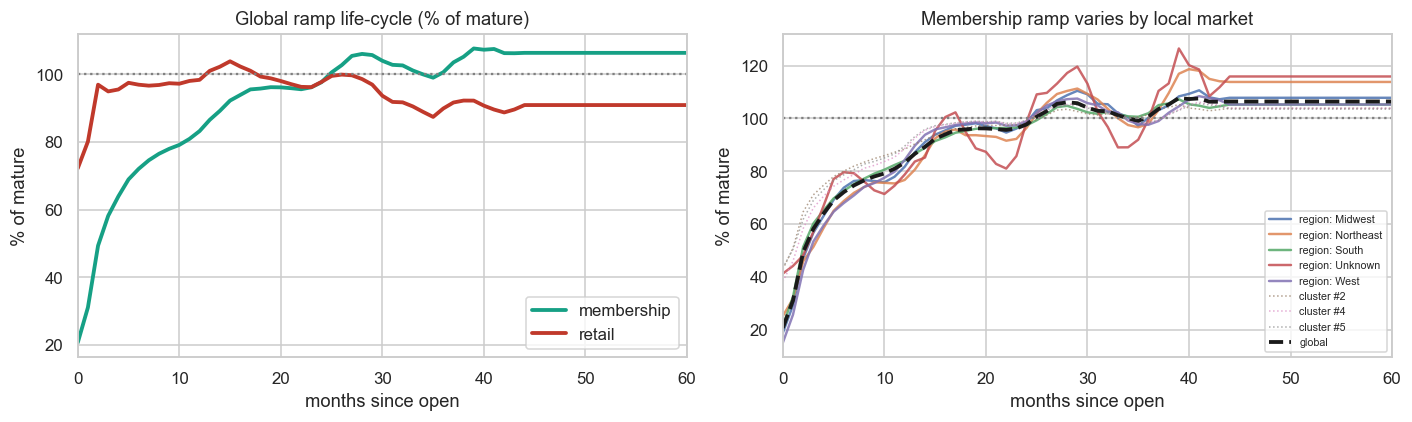

In [5]:
gl = art['ramps']['global']; M = np.arange(len(gl['mem']))
print('ramp life-cycles learned:', art['ramps']['support'])
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(M, gl['mem']*100, lw=2.5, color='#16a085', label='membership')
ax[0].plot(M, gl['ret']*100, lw=2.5, color='#c0392b', label='retail')
ax[0].axhline(100,ls=':',c='gray')
ax[0].set(title='Global ramp life-cycle (% of mature)', xlabel='months since open', ylabel='% of mature', xlim=(0,60)); ax[0].legend()
# membership ramp differs by local market (region curves + a few clusters)
for r,cur in art['ramps']['region'].items():
    ax[1].plot(M, cur['mem']*100, lw=1.6, alpha=.85, label=f'region: {r}')
for c in list(art['ramps']['cluster'])[:3]:
    ax[1].plot(M, art['ramps']['cluster'][c]['mem']*100, lw=1, ls=':', alpha=.7, label=f'cluster #{c}')
ax[1].plot(M, gl['mem']*100, lw=2.5, color='k', ls='--', label='global')
ax[1].axhline(100,ls=':',c='gray')
ax[1].set(title='Membership ramp varies by local market', xlabel='months since open', ylabel='% of mature', xlim=(0,60)); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG/'cs2_ramp.png',bbox_inches='tight'); plt.show()

## 4. Held-out trajectory validation

The real test: predict each held-out site's **actual** monthly trajectory **from location + operator only** (no history), via `plateau(out-of-fold) × ramp`. Compares predicted vs actual over months 1–36.

Held-out trajectory error (median APE): m=1 47% | m=12 32% | m=24 31% | m=36 35%


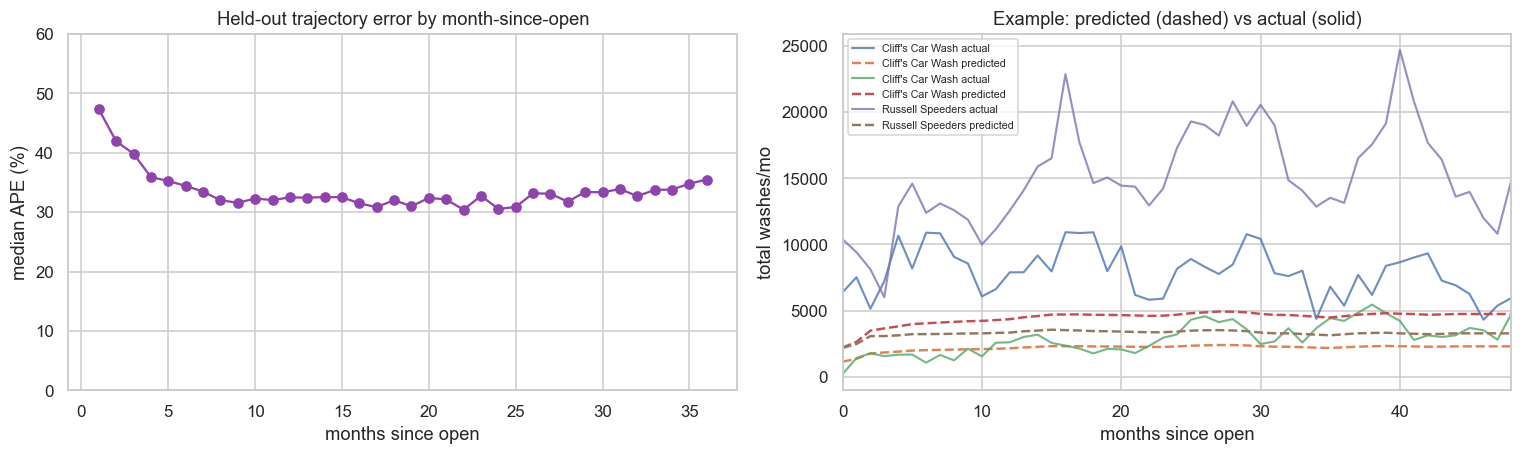

In [6]:
# actual monthly trajectory per labelled site
P = panel.merge(site[['site_key','op_start']], on='site_key', how='left', suffixes=('','_s'))
P['m']=(P.date.dt.year-P.op_start.dt.year)*12+(P.date.dt.month-P.op_start.dt.month)
act = P[P.site_key.isin(L.site_key)].pivot_table(index='site_key', columns='m', values='tot_wash_count')
# predicted trajectory = oof plateau * total ramp (using each site's predicted share)
ms = lgb.LGBMRegressor(n_estimators=400,learning_rate=0.03,num_leaves=31,min_child_samples=20,verbose=-1)
# oof share
sh_oof=np.zeros(len(L))
for tr,te in KFold(5,shuffle=True,random_state=0).split(X):
    ms.fit(X.iloc[tr], L.share.values[tr], categorical_feature=cm.CAT); sh_oof[te]=ms.predict(X.iloc[te])
sh_oof=np.clip(sh_oof,0.05,0.95)
plat_oof=np.expm1(oof)
errs=[]; examples=[]
for i,(_,r) in enumerate(L.reset_index().iterrows()):
    sk=r.site_key
    if sk not in act.index: continue
    pred_traj = plat_oof[i]*(sh_oof[i]*gl['mem']+(1-sh_oof[i])*gl['ret'])  # global ramp (held-out approximation)
    av = act.loc[sk]
    for m in range(1,37):
        if m in av.index and np.isfinite(av[m]) and av[m]>0:
            errs.append((m, abs(pred_traj[m]-av[m])/av[m]))
    if len(examples)<3 and r.mat_total>3000 and (act.loc[sk].reindex(range(0,37)).notna().sum()>30):
        examples.append((sk, r.client_name, av.reindex(range(0,61)).values, pred_traj[:61]))
E=pd.DataFrame(errs, columns=['m','ape'])
byh=E.groupby('m').ape.median()*100
print('Held-out trajectory error (median APE): m=1 %.0f%% | m=12 %.0f%% | m=24 %.0f%% | m=36 %.0f%%'%(
    byh.get(1,np.nan),byh.get(12,np.nan),byh.get(24,np.nan),byh.get(36,np.nan)))
fig,ax=plt.subplots(1,2,figsize=(14,4.3))
ax[0].plot(byh.index, byh.values, '-o', color='#8e44ad'); ax[0].set(title='Held-out trajectory error by month-since-open',
    xlabel='months since open', ylabel='median APE (%)', ylim=(0,max(60,byh.max()*1.1)))
for sk,nm,av,pr in examples:
    mm=np.arange(len(av)); ax[1].plot(mm, av, lw=1.4, alpha=.8, label=f'{nm[:16]} actual')
    ax[1].plot(np.arange(len(pr)), pr, '--', lw=1.6, label=f'{nm[:16]} predicted')
ax[1].set(title='Example: predicted (dashed) vs actual (solid)', xlabel='months since open', ylabel='total washes/mo', xlim=(0,48)); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG/'cs3_heldout.png',bbox_inches='tight'); plt.show()

## 5. Drop-a-pin example forecasts

Pick a couple of real locations and forecast the next 5 years (with P10–P90 bands), with and without a known operator.

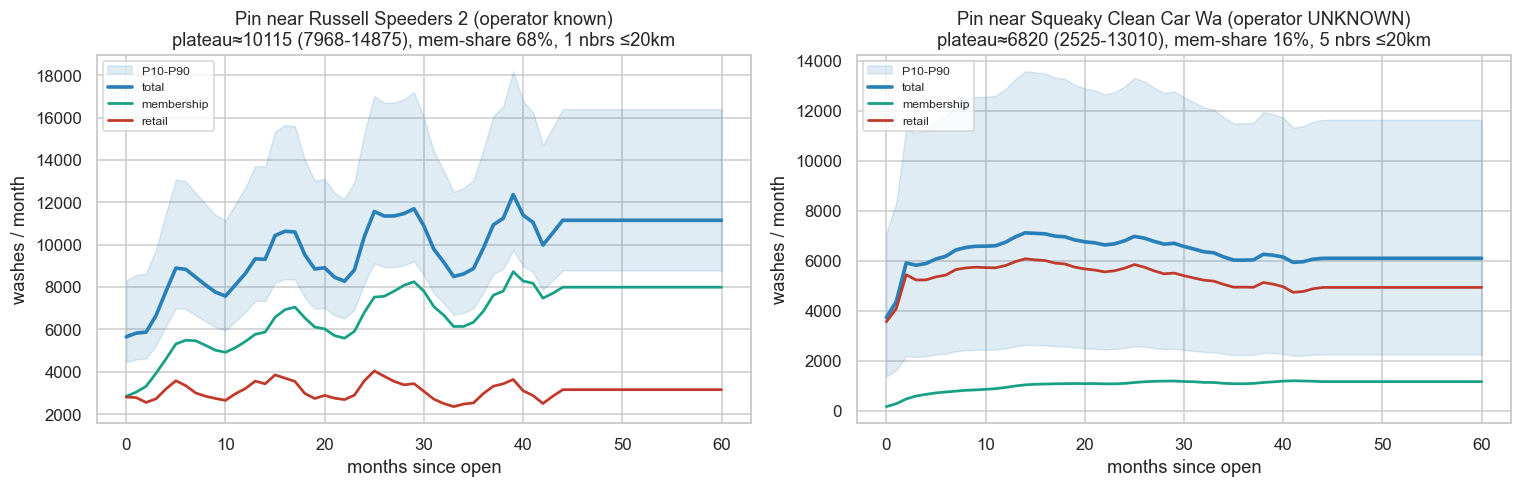

In [7]:
def plot_forecast(ax, lat, lon, brand, title):
    traj,info=cm.predict_site(lat,lon,brand=brand)
    g=traj.set_index('month')
    ax.fill_between(g.index, g.total_lo, g.total_hi, color='#2980b9', alpha=.15, label='P10-P90')
    ax.plot(g.index, g.total_med, color='#2980b9', lw=2.4, label='total')
    ax.plot(g.index, g.mem_med, color='#16a085', lw=1.8, label='membership')
    ax.plot(g.index, g.ret_med, color='#c0392b', lw=1.8, label='retail')
    ax.set(title=f'{title}\nplateau≈{info["plateau_med"]:.0f} ({info["plateau_lo"]:.0f}-{info["plateau_hi"]:.0f}), '
                 f'mem-share {info["mem_share"]:.0%}, {info["n_neighbours_20km"]} nbrs ≤20km',
           xlabel='months since open', ylabel='washes / month'); ax.legend(fontsize=8)
S2=art['sites_rl']; r1=S2[S2.mat_total>4000].iloc[3]; r2=S2[S2.mat_total.between(1500,3000)].iloc[7]
fig,ax=plt.subplots(1,2,figsize=(14,4.6))
plot_forecast(ax[0], r1.lat, r1.lon, r1.client_id, f'Pin near {r1.client_name[:20]} (operator known)')
plot_forecast(ax[1], r2.lat, r2.lon, None, f'Pin near {r2.client_name[:20]} (operator UNKNOWN)')
plt.tight_layout(); plt.savefig(FIG/'cs4_pin_forecast.png',bbox_inches='tight'); plt.show()

## 6. Impact on neighbouring sites

When the new pin opens, each existing neighbour's **retail** is reduced by the learned cannibalization-by-distance (≈ −23% within 5 km fading to −9% at 10–20 km, phased in over 12 months).

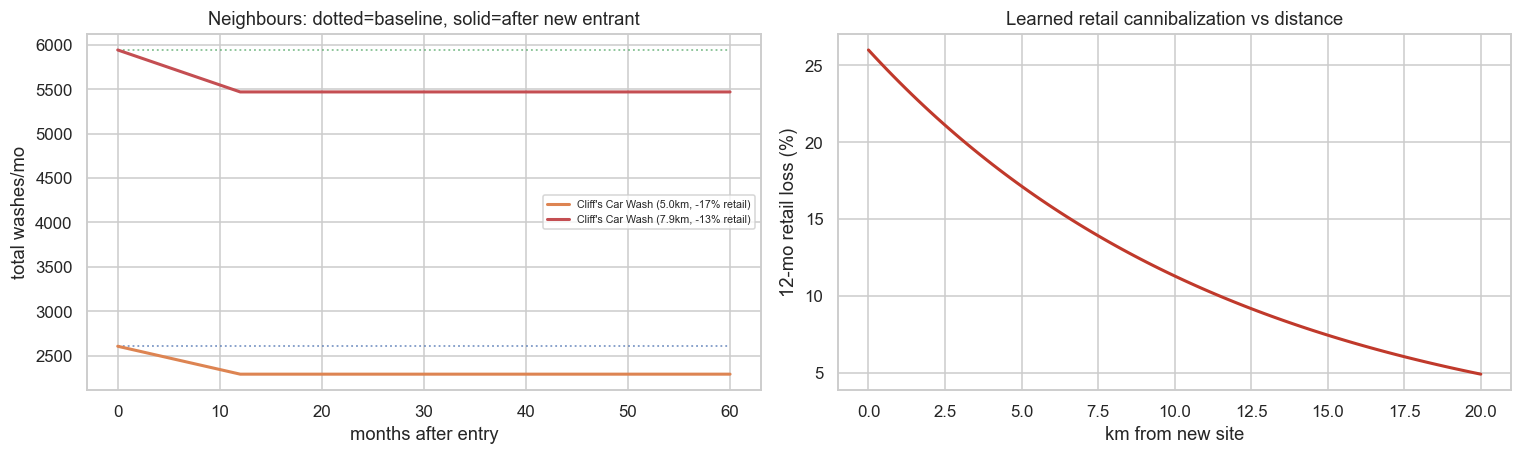

In [8]:
r=art['sites_rl']; r=r[r.mat_total>3000].iloc[2]
nb,months=cm.predict_neighbours(r.lat, r.lon, radius_km=20, max_n=4)
fig,ax=plt.subplots(1,2,figsize=(14,4.3))
for n in nb:
    ax[0].plot(months, n['baseline'], lw=1.2, ls=':', alpha=.7)
    ax[0].plot(months, n['with_entrant'], lw=2, label=f"{n['name'][:16]} ({n['dist_km']:.1f}km, -{n['cannib_ret_pct']:.0f}% retail)")
ax[0].set(title='Neighbours: dotted=baseline, solid=after new entrant', xlabel='months after entry', ylabel='total washes/mo'); ax[0].legend(fontsize=7)
d=np.linspace(0,20,100); ax[1].plot(d, cm._cannib_ret(d)*100, lw=2, color='#c0392b')
ax[1].set(title='Learned retail cannibalization vs distance', xlabel='km from new site', ylabel='12-mo retail loss (%)')
plt.tight_layout(); plt.savefig(FIG/'cs5_neighbours.png',bbox_inches='tight'); plt.show()

## 7. Can MOIRAI do better for cold-start? (seed-and-roll backtest)

The right question: *learn how sites ramp in each cluster and apply that to a new site.* We tested whether **MOIRAI** does this better than the parametric ramp. MOIRAI can't read a zero-history site, so we **seed** it with the cluster's opening trajectory (and separately a textured *analog sibling's* first 6 months, scaled to the same level) and let it **roll forward** to month 36. **Leave-one-opening-out** on real openings, both methods sharing the same plateau level — so this is purely a *trajectory-shape* contest. (`streamlits/moirai_seedroll_worker.py` runs MOIRAI in the isolated venv; cached to `artifacts/`.)

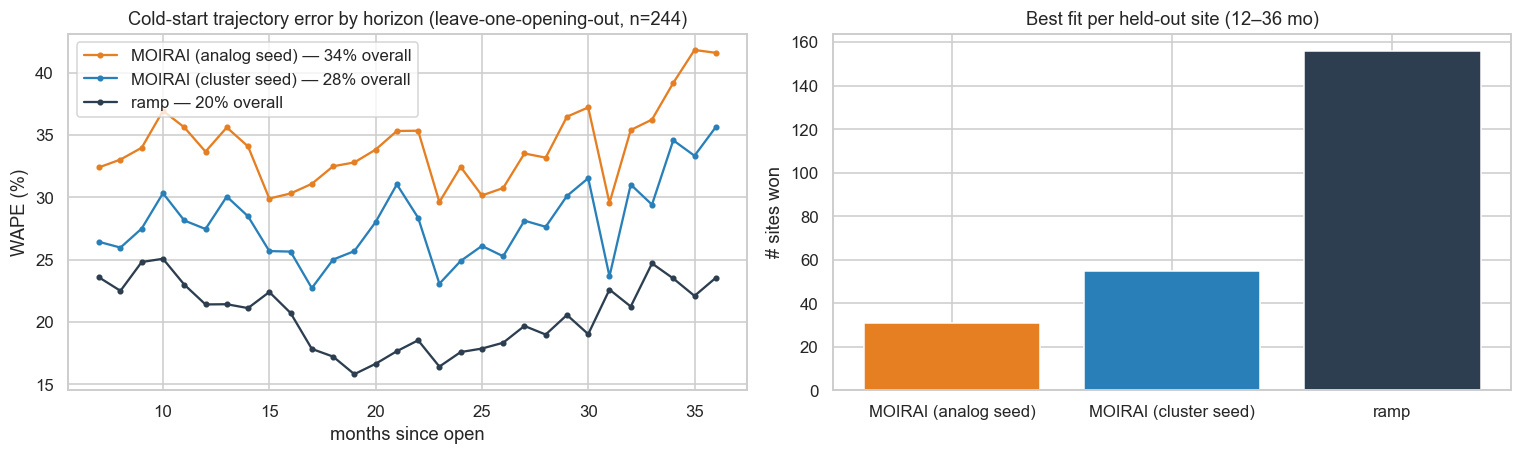

Overall WAPE: {'MOIRAI (analog seed)': 34.1, 'MOIRAI (cluster seed)': 28.1, 'ramp': 20.5}
VERDICT: the learned per-cluster RAMP wins (156/244 sites). MOIRAI seed+roll drifts over the 30-mo horizon.
=> The cluster temporal trajectory is best applied as the learned ramp curve, NOT a MOIRAI rollout. Ramp kept.


In [9]:
import json
ART = Path('artifacts')
inp = json.load(open(ART/'seedroll_inputs.json')); mo = json.load(open(ART/'seedroll_moirai.json'))
K, H = inp[0]['K'], inp[0]['H']
recs = []
for it in inp:
    sk=it['site_key']; act=it['actual']; ramp=it['ramp_pred']; mm=mo.get(sk,{})
    for m in range(K+1, H+1):
        a=act[m]
        if a is None or a<=0: continue
        d={'ramp':ramp[m]}
        if mm.get('cluster'): d['MOIRAI (cluster seed)']=mm['cluster'][m-(K+1)]
        if mm.get('analog'):  d['MOIRAI (analog seed)'] =mm['analog'][m-(K+1)]
        for meth,pv in d.items(): recs.append((m,meth,abs(pv-a),a))
B=pd.DataFrame(recs,columns=['m','method','ae','act']); wape=lambda g: g.ae.sum()/g.act.sum()*100
overall=B.groupby('method').apply(wape, include_groups=False)
piv=B.groupby(['m','method']).apply(wape, include_groups=False).unstack()
colors={'ramp':'#2c3e50','MOIRAI (cluster seed)':'#2980b9','MOIRAI (analog seed)':'#e67e22'}
fig,ax=plt.subplots(1,2,figsize=(14,4.3))
for c in piv.columns: ax[0].plot(piv.index, piv[c], '-o', ms=3, color=colors.get(c), label=f'{c} — {overall[c]:.0f}% overall')
ax[0].set(title=f'Cold-start trajectory error by horizon (leave-one-opening-out, n={len(inp)})', xlabel='months since open', ylabel='WAPE (%)'); ax[0].legend()
win={}
for it in inp:
    sk=it['site_key']; act=it['actual']; ramp=it['ramp_pred']; mm=mo.get(sk,{}); err={}; den=0.0
    for m in range(12,H+1):
        a=act[m]
        if a is None or a<=0: continue
        den+=a; err['ramp']=err.get('ramp',0)+abs(ramp[m]-a)
        if mm.get('cluster'): err['MOIRAI (cluster seed)']=err.get('MOIRAI (cluster seed)',0)+abs(mm['cluster'][m-(K+1)]-a)
        if mm.get('analog'):  err['MOIRAI (analog seed)'] =err.get('MOIRAI (analog seed)',0)+abs(mm['analog'][m-(K+1)]-a)
    if den>0: b=min(err,key=err.get); win[b]=win.get(b,0)+1
ax[1].bar(list(win), list(win.values()), color=[colors.get(k) for k in win]); ax[1].set(title='Best fit per held-out site (12–36 mo)', ylabel='# sites won')
plt.tight_layout(); plt.savefig(FIG/'cs6_seedroll.png',bbox_inches='tight'); plt.show()
print('Overall WAPE:', {k:round(v,1) for k,v in overall.to_dict().items()})
print(f'VERDICT: the learned per-cluster RAMP wins ({win.get("ramp",0)}/{len(inp)} sites). MOIRAI seed+roll drifts over the 30-mo horizon.')
print('=> The cluster temporal trajectory is best applied as the learned ramp curve, NOT a MOIRAI rollout. Ramp kept.')

## 8. Does fine-tuning MOIRAI close the gap?

We **fine-tuned** moirai-1.1-R-small on the panel (`streamlits/moirai_finetune.py`, 500 steps, full fine-tune on a **1,364-site train split**) and re-ran both backtests on **583 held-out sites disjoint from training** (no leakage), zero-shot vs fine-tuned (`moirai_ft_eval.py`). This settles whether fine-tuning helps — separately for *existing-site* forecasting and for *cold-start*.

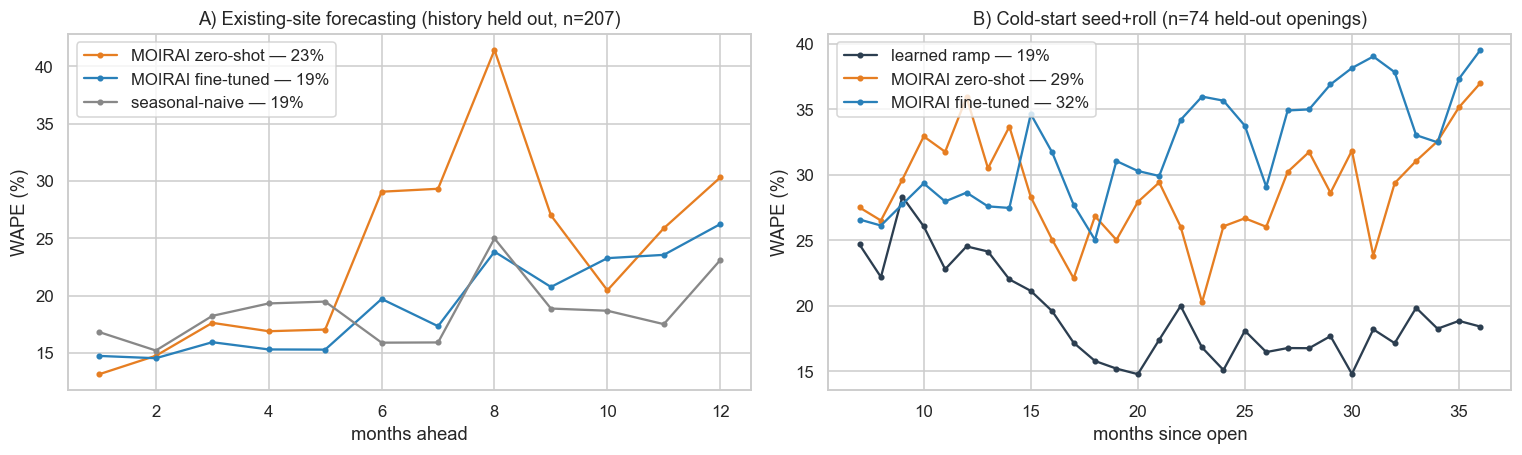

A) existing-site WAPE: zero-shot 23% -> fine-tuned 19% (naive 19%) — fine-tuning helps, ~ties naive
B) cold-start WAPE: ramp 19% vs fine-tuned MOIRAI 32% — ramp still wins; fine-tuning does NOT fix cold-start drift


In [10]:
import json
fe = json.load(open(Path('artifacts')/'ft_eval_results.json'))
E = pd.DataFrame(fe['existing']); C = pd.DataFrame(fe['coldstart'])
wape = lambda df,c: (df[c]-df.actual).abs().sum()/df.actual.abs().sum()*100
fig,ax=plt.subplots(1,2,figsize=(14,4.3))
# A) existing-site: zero-shot vs fine-tuned vs seasonal-naive
for c,col,lab in [('zeroshot','#e67e22','MOIRAI zero-shot'),('finetuned','#2980b9','MOIRAI fine-tuned'),('snaive','#888','seasonal-naive')]:
    ax[0].plot(range(1,13),[wape(E[E.h==h],c) for h in range(1,13)],'-o',ms=3,color=col,label=f'{lab} — {wape(E,c):.0f}%')
ax[0].set(title=f'A) Existing-site forecasting (history held out, n={E.site_key.nunique()})', xlabel='months ahead', ylabel='WAPE (%)'); ax[0].legend()
# B) cold-start: ramp vs zero-shot vs fine-tuned
for c,col,lab in [('ramp','#2c3e50','learned ramp'),('zeroshot','#e67e22','MOIRAI zero-shot'),('finetuned','#2980b9','MOIRAI fine-tuned')]:
    g=C.groupby('m').apply(lambda d: wape(d,c), include_groups=False)
    ax[1].plot(g.index,g.values,'-o',ms=3,color=col,label=f'{lab} — {wape(C,c):.0f}%')
ax[1].set(title=f'B) Cold-start seed+roll (n={C.site_key.nunique()} held-out openings)', xlabel='months since open', ylabel='WAPE (%)'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'cs7_finetune.png',bbox_inches='tight'); plt.show()
print('A) existing-site WAPE: zero-shot %.0f%% -> fine-tuned %.0f%% (naive %.0f%%) — fine-tuning helps, ~ties naive'%(wape(E,'zeroshot'),wape(E,'finetuned'),wape(E,'snaive')))
print('B) cold-start WAPE: ramp %.0f%% vs fine-tuned MOIRAI %.0f%% — ramp still wins; fine-tuning does NOT fix cold-start drift'%(wape(C,'ramp'),wape(C,'finetuned')))

## 9. Conclusions & how to use

**What's learnable, and how well.**
- **Ramp life-cycle — solved (~17%); granularity barely matters.** Membership ~80% of mature by ~7 mo; retail near-full from month 1; plateau ~18–24 mo. Thorough 5-fold test (865 sites): region / global / shrunk-cluster all ≈ **17.4% WAPE**; only un-shrunk per-cluster is mildly worse (~18.6%). We use region-pooled (simplest, tied-best). The ramp is near its ceiling — the **plateau *level* (~27%) is the bottleneck**, not the shape.
- **Plateau level — moderate, operator-driven.** Location alone barely beats a median guess (R²≈0.1); adding the **operator/brand** lifts it to **R²≈0.3, ~28% median error** — an operator's sites share a scale, the local market modulates. A pin in a **fresh area** (no neighbours, unknown operator) is only a weak region prior.
- **Neighbour cannibalization — clear & distance-graded**, reused from the MOIRAI counterfactual (§7-B of `moirai_ts.ipynb`).
- **Why not MOIRAI for the new site? We tested it (§7).** Seeding MOIRAI with the cluster's opening trajectory (or an analog sibling's real early months) and rolling forward **loses to the learned ramp**: WAPE 28–34% vs **20%**, ramp wins **156/244** sites, gap widening with horizon. Autoregressive rollout from a short seed drifts; the per-cluster ramp curve already encodes the shape→plateau directly. So the cluster's temporal life-cycle is best applied **as the learned ramp**, and MOIRAI stays where it wins — neighbour cannibalization and forecasting existing sites that have history.
- **Does fine-tuning MOIRAI change this? Tested (§8).** Fine-tuning on the panel **improves existing-site forecasting** (WAPE 23%→19%, now ~level with seasonal-naive, better at short horizons) — so it helps the regime *with history*. But it **does not help cold-start**: the ramp still wins **19% vs 32%**, because rolling from a 7-month seed drifts *structurally* (an architecture limit, not a weights one). Bottom line: use **fine-tuned MOIRAI for existing-site / neighbour forecasts**, and the **learned ramp for the new pin**.

**Use it.** `coldstart_model.predict_site(lat, lon, brand=...)` → 5-yr trajectory + bands; `predict_neighbours(lat, lon)` → neighbour impacts. Both are wired into the explorer app (**"📍 Drop-a-pin forecast"** mode): click/enter a location, pick an operator (or *unknown*), optionally override the plateau or set year-3–5 growth, and read the expected counts for the new site **and** its neighbours.

**Limitations.** No external demographics (population/income/traffic) — the biggest missing driver of volume; plateau bands are wide and honest; years 3–5 are a *plateau scenario* (the drift controls are scenario knobs, not predictions); cannibalization is the average gradient, not site-specific.